# Librerías

In [2]:
import pandas as pd 
import seaborn as sns
import requests

import matplotlib.pyplot as plt

# Constantes

In [3]:
PATH = '../data/'

# Lectura de datos

In [4]:
df = pd.read_csv(PATH + 'results_gemini.csv')

# Procesamiento y exploeación

In [5]:
df["references"] = df.references.apply(
    lambda x: str(x).replace('[', '').replace(']', '').split(','))

<Axes: >

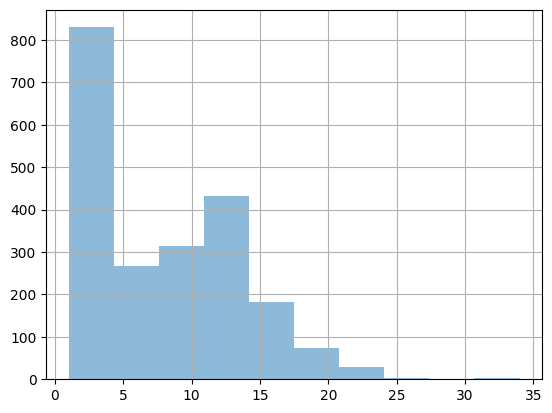

In [6]:
df['len_references'] = df['references'].apply(lambda x: len(x))
df['len_references'].hist(alpha = 0.5)

# Sacar links reales

In [7]:
def obtener_url_real(url):
    try:
        # Hacemos una petición HEAD para no descargar toda la página, solo ver a dónde va
        response = requests.head(url, allow_redirects=True, timeout=5)
        return response.url
    except Exception as e:
        return f"Error: {e}"
    
def obtener_urls(list_url):
    return [
        obtener_url_real(url) for url in list_url
    ]

In [8]:
df['references_real'] = df['references'].apply(obtener_urls)

In [10]:
df['references_real']

0       [Error: No connection adapters were found for ...
1       [Error: No connection adapters were found for ...
2       [Error: No connection adapters were found for ...
3       [Error: No connection adapters were found for ...
4       [Error: No connection adapters were found for ...
                              ...                        
2130    [Error: No connection adapters were found for ...
2131    [Error: No connection adapters were found for ...
2132    [Error: No connection adapters were found for ...
2133    [Error: No connection adapters were found for ...
2134    [Error: No connection adapters were found for ...
Name: references_real, Length: 2135, dtype: object